## Instructions
1. Add the required datasets to your Kaggle notebook first (Add Input in the right panel). If a file path fails, run the first code cell below and copy the exact path it prints.
2. Run the setup cells (imports and dataset loading) before starting any question.
3. For every question, read the task list, then read the "How to do it" guidance, then write your code in the empty code cell below it. You can add more code cells if you need them.
4. Always look at your data before working on it: check the first rows, the column names and the data types. Column names differ between datasets, so do not guess them.
5. After important outputs and every plot, write one or two lines in a markdown cell explaining what you observe.
6. Before submitting, restart the kernel and run all cells from top to bottom. There should be no errors.


## Setup

In [57]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/saurabhbadole/restaurant-tips-dataset/tips.csv
/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv
/kaggle/input/datasets/ishanshrivastava28/superstore-sales/Superstore.csv
/kaggle/input/datasets/ishanshrivastava28/superstore-sales/Superstore.xlsx
/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/ciochdawid/dailydelhiclimatetrain-csv/DailyDelhiClimateTrain.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv
/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Datasets used: tips, titanic, iris, superstore, Delhi daily climate, UCI adult census, diabetes prediction and house data.

In [59]:
tips = pd.read_csv('/kaggle/input/datasets/saurabhbadole/restaurant-tips-dataset/tips.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
iris = pd.read_csv('/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv')
store = pd.read_csv('/kaggle/input/datasets/ishanshrivastava28/superstore-sales/Superstore.csv', encoding='latin-1')
climate = pd.read_csv('/kaggle/input/datasets/ciochdawid/dailydelhiclimatetrain-csv/DailyDelhiClimateTrain.csv')
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

---
# Part 1: NumPy

## Question 1: Creating NumPy arrays

**Tasks**

- Create 1D, 2D, 3D and 4D arrays using np.array().
- Create 1D, 2D, 3D and 4D arrays using arange() and reshape().
- Create arrays using ones and zeros.
- Create arrays using random.
- Create an array using linspace.

**How to do it**

Start with np.array: write nested lists, and remember that every extra level of brackets adds one dimension. For arange and reshape, first make a flat sequence of numbers, then reshape it. The numbers in the new shape multiplied together must equal the total number of elements, otherwise reshape will fail. For ones and zeros, you give the shape you want instead of the values. For random, try three kinds: decimal numbers between 0 and 1, whole numbers within a range you choose, and numbers from a normal distribution; set a seed first if you want repeatable results. For linspace, you give a start, an end and how many points you want, and it spaces them evenly (unlike arange, which works with a step size). After creating each array, print it and check its number of dimensions and its shape to confirm it is what you intended.

In [60]:
import numpy as np

# 1. np.array()
print(np.array([1, 2, 3]))                 # 1D
print(np.array([[1, 2], [3, 4]]))          # 2D
print(np.array([[[1, 2], [3, 4]]]))        # 3D
print(np.array([[[[1, 2]]]]))              # 4D

# 2. arange() + reshape()
print(np.arange(6))                        # 1D
print(np.arange(6).reshape(2, 3))          # 2D
print(np.arange(8).reshape(2, 2, 2))       # 3D
print(np.arange(16).reshape(2, 2, 2, 2))   # 4D

# 3. Ones and Zeros
print(np.ones((2, 2)))
print(np.zeros((2, 2)))

# 4. Random
np.random.seed(1)
print(np.random.random((2, 2)))             # decimal
print(np.random.randint(1, 10, (2, 2)))    # integer
print(np.random.normal(0, 1, (2, 2)))       # normal

# 5. Linspace
print(np.linspace(0, 10, 5))


[1 2 3]
[[1 2]
 [3 4]]
[[[1 2]
  [3 4]]]
[[[[1 2]]]]
[0 1 2 3 4 5]
[[0 1 2]
 [3 4 5]]
[[[0 1]
  [2 3]]

 [[4 5]
  [6 7]]]
[[[[ 0  1]
   [ 2  3]]

  [[ 4  5]
   [ 6  7]]]


 [[[ 8  9]
   [10 11]]

  [[12 13]
   [14 15]]]]
[[1. 1.]
 [1. 1.]]
[[0. 0.]
 [0. 0.]]
[[4.17022005e-01 7.20324493e-01]
 [1.14374817e-04 3.02332573e-01]]
[[1 1]
 [2 8]]
[[-1.10593508 -1.65451545]
 [-2.3634686   1.13534535]]
[ 0.   2.5  5.   7.5 10. ]


## Question 2: Arrays from the tips dataset and array attributes

**Tasks**

- Create a 1D array of the tip column.
- Create a 2D array of the tip and total_bill columns.
- Practice ndim, shape, size and itemsize with at least 2 examples each.
- Change the data type of an array using astype() and compare the memory used before and after.

**How to do it**

Take the columns out of the dataframe and convert them into NumPy arrays. For the 2D array, select both columns together as one group so the result has two columns; its shape should be the number of rows by 2. For the attributes, use different arrays you created in Question 1 and in this question. Write a short comment next to each output saying what it means: ndim is the number of dimensions, shape is the size along each dimension, size is the total number of elements and itemsize is the bytes used by one element. For the data type change, convert a float array to a smaller float type or to integers, save the result in a new variable, and compare the item size and total bytes of the two arrays. Note that the conversion does not change the original array.

In [61]:
import numpy as np

# 1. 1D array of tip
tip = tips["tip"].to_numpy()
print("Tip array:", tip)

# 2. 2D array of tip and total_bill
two_col = tips[["tip", "total_bill"]].to_numpy()
print("2D array:")
print(two_col)


# 3. Array attributes

a = np.array([1, 2, 3, 4])

print("ndim:", a.ndim)       # number of dimensions
print("shape:", a.shape)     # size of each dimension
print("size:", a.size)       # total number of elements
print("itemsize:", a.itemsize) # bytes per element


b = np.array([[1, 2], [3, 4]])

print("ndim:", b.ndim)
print("shape:", b.shape)
print("size:", b.size)
print("itemsize:", b.itemsize)


# 4. Change data type using astype()

x = tip
y = x.astype("float32")

print("Original itemsize:", x.itemsize)
print("New itemsize:", y.itemsize)

print("Original memory:", x.nbytes)
print("New memory:", y.nbytes)


Tip array: [ 1.01  1.66  3.5   3.31  3.61  4.71  2.    3.12  1.96  3.23  1.71  5.
  1.57  3.    3.02  3.92  1.67  3.71  3.5   3.35  4.08  2.75  2.23  7.58
  3.18  2.34  2.    2.    4.3   3.    1.45  2.5   3.    2.45  3.27  3.6
  2.    3.07  2.31  5.    2.24  2.54  3.06  1.32  5.6   3.    5.    6.
  2.05  3.    2.5   2.6   5.2   1.56  4.34  3.51  3.    1.5   1.76  6.73
  3.21  2.    1.98  3.76  2.64  3.15  2.47  1.    2.01  2.09  1.97  3.
  3.14  5.    2.2   1.25  3.08  4.    3.    2.71  3.    3.4   1.83  5.
  2.03  5.17  2.    4.    5.85  3.    3.    3.5   1.    4.3   3.25  4.73
  4.    1.5   3.    1.5   2.5   3.    2.5   3.48  4.08  1.64  4.06  4.29
  3.76  4.    3.    1.    4.    2.55  4.    3.5   5.07  1.5   1.8   2.92
  2.31  1.68  2.5   2.    2.52  4.2   1.48  2.    2.    2.18  1.5   2.83
  1.5   2.    3.25  1.25  2.    2.    2.    2.75  3.5   6.7   5.    5.
  2.3   1.5   1.36  1.63  1.73  2.    2.5   2.    2.74  2.    2.    5.14
  5.    3.75  2.61  2.    3.5   2.5   2.    2.    3

## Question 3: Mathematical operations on arrays

**Tasks**

- Create two arrays of the same shape and perform scalar and vector operations.
- Find the minimum and maximum tip.
- Find the average total_bill and the average tip.
- Find the median total_bill.
- Find the standard deviation and variance of tip.
- Find the log values of tip.
- Apply round, floor and ceil on the tip array.

**How to do it**

A scalar operation combines an array with a single number (for example adding 5 to every element). A vector operation combines two arrays element by element, so both arrays need the same shape. For the statistics, use the arrays you made from the tips dataset and apply the matching NumPy function for each one. For the 2D array, think about what changes when you calculate along rows versus along columns. Before taking a log, check that the smallest value is greater than zero. For round, floor and ceil, print the first few original values next to each result so you can see the difference between the three. Finally, write one line comparing the mean and the median of total_bill and what that says about the data.

In [62]:
import numpy as np

tip = tips["tip"].to_numpy()
bill = tips["total_bill"].to_numpy()

# 1. Scalar operation
print(tip + 5)
print(tip * 2)

# 2. Vector operation
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(a + b)
print(a * b)

# 3. Minimum and Maximum tip
print("Min tip:", np.min(tip))
print("Max tip:", np.max(tip))

# 4. Average
print("Average bill:", np.mean(bill))
print("Average tip:", np.mean(tip))

# 5. Median
print("Median bill:", np.median(bill))

# 6. Standard deviation and variance
print("Standard deviation:", np.std(tip))
print("Variance:", np.var(tip))

# 7. Log values
print("Log:", np.log(tip))

# 8. Round, Floor and Ceil
print("Original:", tip[:5])
print("Round:", np.round(tip[:5]))
print("Floor:", np.floor(tip[:5]))
print("Ceil:", np.ceil(tip[:5]))

# 9. Mean vs Median
print("Mean:", np.mean(bill))
print("Median:", np.median(bill))


[ 6.01  6.66  8.5   8.31  8.61  9.71  7.    8.12  6.96  8.23  6.71 10.
  6.57  8.    8.02  8.92  6.67  8.71  8.5   8.35  9.08  7.75  7.23 12.58
  8.18  7.34  7.    7.    9.3   8.    6.45  7.5   8.    7.45  8.27  8.6
  7.    8.07  7.31 10.    7.24  7.54  8.06  6.32 10.6   8.   10.   11.
  7.05  8.    7.5   7.6  10.2   6.56  9.34  8.51  8.    6.5   6.76 11.73
  8.21  7.    6.98  8.76  7.64  8.15  7.47  6.    7.01  7.09  6.97  8.
  8.14 10.    7.2   6.25  8.08  9.    8.    7.71  8.    8.4   6.83 10.
  7.03 10.17  7.    9.   10.85  8.    8.    8.5   6.    9.3   8.25  9.73
  9.    6.5   8.    6.5   7.5   8.    7.5   8.48  9.08  6.64  9.06  9.29
  8.76  9.    8.    6.    9.    7.55  9.    8.5  10.07  6.5   6.8   7.92
  7.31  6.68  7.5   7.    7.52  9.2   6.48  7.    7.    7.18  6.5   7.83
  6.5   7.    8.25  6.25  7.    7.    7.    7.75  8.5  11.7  10.   10.
  7.3   6.5   6.36  6.63  6.73  7.    7.5   7.    7.74  7.    7.   10.14
 10.    8.75  7.61  7.    8.5   7.5   7.    7.    8.    8.48  

## Question 4: Indexing, slicing, stacking and splitting

**Tasks**

- Create one 1D, one 2D and one 3D array, and write at least 5 indexing or slicing examples for each.
- Using the arrays d and e given below, join them with hstack and vstack.
- Split the joined results back using hsplit and vsplit.

**How to do it**

For indexing, remember counting starts at zero and negative numbers count from the end. For slicing, the pattern is start, stop and step, and the stop position is not included. In 2D arrays, you give one slice for rows and one for columns. In 3D arrays, you give one choice for each of the three axes. Include a mix of examples: a single element, a whole row or column, a range, a step, and a reverse order. You can also try selecting by a condition. For stacking, vstack puts one array below the other (rows add up) and hstack puts them side by side (columns add up); predict the new shape before you run it. For splitting, the array must divide evenly into the number of parts you ask for, so choose the number of parts according to the number of columns or rows.

In [63]:
import numpy as np

d = np.arange(27).reshape(3,9)
e = np.arange(28,55).reshape(3,9)

h = np.hstack((d,e))
print(h)
print(h.shape)

v = np.vstack((d,e))
print(v)
print(v.shape)

print(np.hsplit(h,2))
print(np.vsplit(v,2))


[[ 0  1  2  3  4  5  6  7  8 28 29 30 31 32 33 34 35 36]
 [ 9 10 11 12 13 14 15 16 17 37 38 39 40 41 42 43 44 45]
 [18 19 20 21 22 23 24 25 26 46 47 48 49 50 51 52 53 54]]
(3, 18)
[[ 0  1  2  3  4  5  6  7  8]
 [ 9 10 11 12 13 14 15 16 17]
 [18 19 20 21 22 23 24 25 26]
 [28 29 30 31 32 33 34 35 36]
 [37 38 39 40 41 42 43 44 45]
 [46 47 48 49 50 51 52 53 54]]
(6, 9)
[array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23, 24, 25, 26]]), array([[28, 29, 30, 31, 32, 33, 34, 35, 36],
       [37, 38, 39, 40, 41, 42, 43, 44, 45],
       [46, 47, 48, 49, 50, 51, 52, 53, 54]])]
[array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23, 24, 25, 26]]), array([[28, 29, 30, 31, 32, 33, 34, 35, 36],
       [37, 38, 39, 40, 41, 42, 43, 44, 45],
       [46, 47, 48, 49, 50, 51, 52, 53, 54]])]


In [64]:
d = np.arange(27).reshape(3,9)
e = np.arange(28,55).reshape(3,9)

---
# Part 2: Pandas

## Question 5: Series

**Tasks**

- Create a Series from a list, from a dictionary, and from a dataframe column.
- Understand a Series using head, tail, sample, size, dtype, astype, index and values.
- Change the data type of a Series.
- Apply count, sum, product, min, max, mean, median, mode, describe, std and var on a Series.
- Do 3 slicing operations on a Series.

**How to do it**

When creating a Series from a dictionary, the keys become the index and the values become the data. A single column taken from a dataframe is already a Series; check its type, and notice the difference between selecting one column and selecting a group of columns. Use a numeric column such as tip or total_bill for the exploration and math operations. Note which items are attributes (written without brackets) and which are methods (written with brackets). For the type change, store the converted result in a new variable and check its data type. The mode returns a Series, so take the first value if you need one number. For slicing, try one by position, one by label and one by condition, and remember the difference in whether the end point is included.

In [65]:
import pandas as pd

# Series from list
s1 = pd.Series([10, 20, 30, 40, 50])
print(s1)

# Series from dictionary
s2 = pd.Series({"a": 10, "b": 20, "c": 30})
print(s2)

# Series from dataframe column
s3 = tips["tip"]
print(s3)

# Series information
print(s3.head())
print(s3.tail())
print(s3.sample(3))
print(s3.size)
print(s3.dtype)
print(s3.index)
print(s3.values)

# Change data type
s4 = s3.astype("float32")
print(s4.dtype)

# Mathematical operations
print(s3.count())
print(s3.sum())
print(s3.prod())
print(s3.min())
print(s3.max())
print(s3.mean())
print(s3.median())
print(s3.mode().iloc[0])
print(s3.describe())
print(s3.std())
print(s3.var())

# Slicing
print(s3.iloc[0:5])
print(s3.loc[0:5])
print(s3[s3 > 5])

0    10
1    20
2    30
3    40
4    50
dtype: int64
a    10
b    20
c    30
dtype: int64
0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64
0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, dtype: float64
79     2.71
12     1.57
118    1.80
Name: tip, dtype: float64
244
float64
RangeIndex(start=0, stop=244, step=1)
[ 1.01  1.66  3.5   3.31  3.61  4.71  2.    3.12  1.96  3.23  1.71  5.
  1.57  3.    3.02  3.92  1.67  3.71  3.5   3.35  4.08  2.75  2.23  7.58
  3.18  2.34  2.    2.    4.3   3.    1.45  2.5   3.    2.45  3.27  3.6
  2.    3.07  2.31  5.    2.24  2.54  3.06  1.32  5.6   3.    5.    6.
  2.05  3.    2.5   2.6   5.2   1.56  4.34  3.51  3.    1.5   1.76  6.73
  3.21  2.    1.98  3.76  2.64  3.15  2.47  1.    2.01  2.09  1.97  3.
  3.14  5.    2.2   1.25  3.08  4.

## Question 6: DataFrame basics

**Tasks**

- Create a dataframe from a list with at least 3 columns and 5 rows.
- Use head, tail, sample, info, isnull and duplicated on the titanic dataset.
- Check shape, dtypes, columns and values of the dataframe.
- Apply count, sum, product, min, max, mean, median, mode, describe, std and var on one numeric column.

**How to do it**

When creating a dataframe from a list of rows, give the column names yourself. For the titanic dataset, read the info output carefully to see which columns have missing values and what their types are. For isnull and duplicated, do not just print the large result; summarize it into counts per column or a total count. Write a one-line comment for each attribute explaining what it tells you about the data. For the numeric column operations, pick a column such as Fare or Age, and think about how missing values affect the count and the average.

In [66]:
import pandas as pd

# DataFrame from list
data = [
    [1, "A", 20],
    [2, "B", 30],
    [3, "C", 25],
    [4, "D", 40],
    [5, "E", 35]
]

df = pd.DataFrame(data, columns=["ID", "Name", "Age"])
print(df)

# Titanic dataset
titanic = pd.read_csv("/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv")

print(titanic.head())
print(titanic.tail())
print(titanic.sample(5))

titanic.info()

print(titanic.isnull().sum())
print(titanic.duplicated().sum())

# DataFrame information
print(titanic.shape)
print(titanic.dtypes)
print(titanic.columns)
print(titanic.values)

# Numeric column
x = titanic["Fare"]

print(x.count())
print(x.sum())
print(x.prod())
print(x.min())
print(x.max())
print(x.mean())
print(x.median())
print(x.mode().iloc[0])
print(x.describe())
print(x.std())
print(x.var())


   ID Name  Age
0   1    A   20
1   2    B   30
2   3    C   25
3   4    D   40
4   5    E   35
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0    

## Question 7: Selection and filtering

**Tasks**

- From tips, select rows 11 to 20 and the total_bill and tip columns.
- From tips, select rows 0 to 20 and the total_bill, tip and day columns.
- From tips, select customers who came on Sunday and had a total_bill greater than 20.
- From titanic, select passengers who are male and older than 50.
- From tips, select female customers with a tip greater than 5 using the query method.
- Use isin and the not operator in at least one extra example.

**How to do it**

Use label-based selection for some tasks and position-based selection for others, and notice that label-based selection includes the end row while position-based selection does not. For conditions, first check the exact spelling of the category values in the column (capital letters and abbreviations matter). Write each condition separately, put each one in its own brackets, and join them with the and, or, not symbols. For the query method, write the whole condition as one text string using words like and. For isin, give it a list of values to match.

In [67]:

print(tips.loc[11:20, ["total_bill", "tip"]])
print(tips.iloc[0:21, [tips.columns.get_loc("total_bill"),
                       tips.columns.get_loc("tip"),
                       tips.columns.get_loc("day")]])
print(tips[(tips["day"] == "Sun") & (tips["total_bill"] > 20)])
print(titanic[(titanic["Sex"] == "male") & (titanic["Age"] > 50)])
print(tips.query("sex == 'Female' and tip > 5"))
print(tips[tips["day"].isin(["Sat", "Sun"])])
print(tips[~tips["day"].isin(["Sat", "Sun"])])


    total_bill   tip
11       35.26  5.00
12       15.42  1.57
13       18.43  3.00
14       14.83  3.02
15       21.58  3.92
16       10.33  1.67
17       16.29  3.71
18       16.97  3.50
19       20.65  3.35
20       17.92  4.08
    total_bill   tip  day
0        16.99  1.01  Sun
1        10.34  1.66  Sun
2        21.01  3.50  Sun
3        23.68  3.31  Sun
4        24.59  3.61  Sun
5        25.29  4.71  Sun
6         8.77  2.00  Sun
7        26.88  3.12  Sun
8        15.04  1.96  Sun
9        14.78  3.23  Sun
10       10.27  1.71  Sun
11       35.26  5.00  Sun
12       15.42  1.57  Sun
13       18.43  3.00  Sun
14       14.83  3.02  Sun
15       21.58  3.92  Sun
16       10.33  1.67  Sun
17       16.29  3.71  Sun
18       16.97  3.50  Sun
19       20.65  3.35  Sat
20       17.92  4.08  Sat
     total_bill   tip     sex smoker  day    time  size
2         21.01  3.50    Male     No  Sun  Dinner     3
3         23.68  3.31    Male     No  Sun  Dinner     2
4         24.59  3.61  Female

## Question 8: GroupBy on the superstore dataset

**Tasks**

- Group the data by region.
- Find region-wise average sales, average profit and maximum profit.
- Apply multiple aggregate functions (mean, min, max, sum) on region-wise sales.
- Group by region and category, and find average sales.
- Find region and category wise average, minimum, maximum and sum of sales.

**How to do it**

Think of groupby in three steps: choose the column to group by, choose the column to calculate on, and choose the calculation. A grouped object does not show anything by itself, so you must apply a calculation to see results. To apply several calculations at once, give a list of function names. To group by two columns, give them as a list. For two-level results, try converting one level into columns to make the table easier to read. Check the exact column names in the dataset first, including capital letters.

In [68]:
import pandas as pd

# Region wise average sales, profit and maximum profit
print(store.groupby("Region")[["Sales", "Profit"]].agg(["mean", "max"]))

# Region wise sales
print(store.groupby("Region")["Sales"].agg(["mean", "min", "max", "sum"]))

# Region and Category wise average sales
print(store.groupby(["Region", "Category"])["Sales"].mean())

# Region and Category wise sales
print(store.groupby(["Region", "Category"])["Sales"].agg(
    ["mean", "min", "max", "sum"]
))

# Table format
print(store.groupby(["Region", "Category"])["Sales"].agg(
    ["mean", "min", "max", "sum"]
).reset_index())


              Sales                Profit           
               mean        max       mean        max
Region                                              
Central  215.772661  17499.950  17.092709  8399.9760
East     238.336110  11199.968  32.135808  5039.9856
South    241.803645  22638.480  28.857673  3177.4750
West     226.493233  13999.960  33.849032  6719.9808
               mean    min        max          sum
Region                                            
Central  215.772661  0.444  17499.950  501239.8908
East     238.336110  0.852  11199.968  678781.2400
South    241.803645  1.167  22638.480  391721.9050
West     226.493233  0.990  13999.960  725457.8245
Region   Category       
Central  Furniture          340.534644
         Office Supplies    117.458801
         Technology         405.753124
East     Furniture          346.574383
         Office Supplies    120.044425
         Technology         495.278469
South    Furniture          353.309289
         Office Supplies 

## Question 9: Merging and joining

**Tasks**

- Create a dataframe containing student name, faculty, math marks and python marks.
- Find the department-wise student count.
- Find the faculty-wise department count.
- Find the department-wise highest marks in each subject.
- Find the faculty-wise highest marks in each subject.

**How to do it**

Run the three practice tables first and study them: students and results share the student id column, but not every id appears in both, and students connect to departments through the department name. Merge in two steps: first students with results, then the result with departments. Decide the join type deliberately (inner keeps only matching rows, left keeps all students) and explain in one line why some students are missing or have empty marks after your chosen merge. Use the original tables for the count questions and the merged table for the highest marks questions, grouping by department or faculty as needed.

In [69]:
# Students + Results
m1 = pd.merge(students, results, on="student_id", how="left")

# Department + Faculty
m2 = pd.merge(m1, departments, on="department", how="left")

# Department-wise student count
print(students.groupby("department")["student_id"].count())

# Faculty-wise department count
print(departments.groupby("faculty")["department"].count())

# Department-wise highest marks
print(m2.groupby("department")[["math", "python"]].max())

# Faculty-wise highest marks
print(m2.groupby("faculty")[["math", "python"]].max())



department
BBA    5
CSE    9
EEE    6
Name: student_id, dtype: int64
faculty
Business       1
Engineering    3
Name: department, dtype: int64
            math  python
department              
BBA         88.0    92.0
CSE         95.0    96.0
EEE         77.0    80.0
             math  python
faculty                  
Business     88.0    92.0
Engineering  95.0    96.0


In [70]:
students = pd.DataFrame({
    "student_id": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
                   111, 112, 113, 114, 115, 116, 117, 118, 119, 120],
    "name": ["Rahim", "Karim", "Hasan", "Sakib", "Nabil",
             "Tanvir", "Fahim", "Rafi", "Imran", "Shakil",
             "Arif", "Jahid", "Mehedi", "Siam", "Tareq",
             "Rakib", "Adnan", "Nayeem", "Foysal", "Rony"],
    "department": ["CSE", "EEE", "CSE", "BBA", "CSE",
                   "EEE", "CSE", "BBA", "CSE", "EEE",
                   "CSE", "BBA", "EEE", "CSE", "BBA",
                   "CSE", "EEE", "CSE", "BBA", "EEE"]
})

students

,student_id,name,department
0,101,Rahim,CSE
1,102,Karim,EEE
2,103,Hasan,CSE
3,104,Sakib,BBA
4,105,Nabil,CSE
5,106,Tanvir,EEE
6,107,Fahim,CSE
7,108,Rafi,BBA
8,109,Imran,CSE
9,110,Shakil,EEE


In [71]:
results = pd.DataFrame({
    "student_id": [101, 102, 103, 105, 106, 108, 109, 111, 112, 114,
                   121, 122, 123, 124, 125, 126, 127, 128, 129, 130],
    "math": [85, 72, 91, 68, 77, 88, 74, 95, 81, 69,
             78, 84, 92, 73, 89, 67, 80, 94, 76, 83],
    "python": [90, 75, 88, 72, 80, 92, 79, 96, 85, 71,
               82, 87, 95, 76, 91, 70, 84, 93, 78, 86]
})

results

,student_id,math,python
0,101,85,90
1,102,72,75
2,103,91,88
3,105,68,72
4,106,77,80
5,108,88,92
6,109,74,79
7,111,95,96
8,112,81,85
9,114,69,71


In [72]:
departments = pd.DataFrame({
    "dept_id": [1, 2, 3, 4],
    "department": ["CSE", "EEE", "BBA", "Civil"],
    "faculty": ["Engineering", "Engineering", "Business", "Engineering"]
})

departments

,dept_id,department,faculty
0,1,CSE,Engineering
1,2,EEE,Engineering
2,3,BBA,Business
3,4,Civil,Engineering


## Question 10: Time series on the climate dataset

**Tasks**

- Convert the date column into datetime and set it as the index.
- Select the row of 13 January 2015.
- Select all rows in April 2017.
- Select rows from 11 September 2014 to 25 September 2014.
- Calculate month-wise average wind speed and month-wise highest mean temperature.
- Calculate year-wise maximum, minimum and average humidity.
- Create a new column containing the average mean temperature of the previous 10 days.

**How to do it**

The date column is stored as text at first, so convert it to real dates and then make it the index; this is what allows selecting by date. Once the index is a date, you can select a single day, a whole month or a date range by writing the date as text in year-month-day format; a date range includes both end dates. For month-wise and year-wise results, resample the data to the period you want and then apply the calculation (check the dataset's real column names, as the wind speed column may be named differently than you expect). For the previous 10 days average, use a rolling window of 10 days; to make sure today's value is not included, shift the result by one day. Explain in one line why the first rows of the new column are empty.

In [73]:
import pandas as pd

if "date" in climate.columns:
    climate["date"] = pd.to_datetime(climate["date"])
    climate.set_index("date", inplace=True)
else:
    climate.index = pd.to_datetime(climate.index)

# 13 January 2015
print(climate.loc["2015-01-13"])

# April 2017
print(climate[(climate.index >= "2017-04-01") &
              (climate.index <= "2017-04-30")])

# 11 September to 25 September 2014
print(climate[(climate.index >= "2014-09-11") &
              (climate.index <= "2014-09-25")])

# Month-wise average wind speed
print(climate["wind_speed"].groupby(climate.index.month).mean())

# Month-wise highest mean temperature
print(climate["meantemp"].groupby(climate.index.month).mean().max())

# Year-wise humidity
print(climate["humidity"].groupby(climate.index.year).agg(
    ["max", "min", "mean"]
))

# Previous 10 days average temperature
climate["previous_10_days_avg"] = (
    climate["meantemp"].rolling(10).mean().shift(1)
)

print(climate[["meantemp", "previous_10_days_avg"]])


meantemp          12.250
humidity          77.875
wind_speed         4.875
meanpressure    1017.125
Name: 2015-01-13 00:00:00, dtype: float64
Empty DataFrame
Columns: [meantemp, humidity, wind_speed, meanpressure]
Index: []
             meantemp   humidity  wind_speed  meanpressure
date                                                      
2014-09-11  26.571429  85.714286   17.825000   1005.571429
2014-09-12  28.500000  73.000000    1.625000   1005.125000
2014-09-13  29.375000  68.250000    4.162500   1004.000000
2014-09-14  29.125000  65.500000    6.712500   1004.250000
2014-09-15  29.625000  63.125000    6.712500   1004.250000
2014-09-16  30.625000  65.125000    6.250000   1002.250000
2014-09-17  30.625000  61.875000    7.400000   1002.125000
2014-09-18  30.500000  62.375000    6.712500   1003.875000
2014-09-19  31.000000  56.625000    4.175000   1003.500000
2014-09-20  31.125000  55.750000    4.400000   1002.875000
2014-09-21  30.500000  54.875000    5.562500   1003.625000
2014-09-2

---
# Part 3: Missing Values and Outliers

## Question 11: Impute missing values in the UCI dataset

**Tasks**

- Impute the missing values of the occupation column of the UCI dataset.

**How to do it**

Step 1: count the missing values in the occupation column. Step 2: also look at the list of unique values and their counts, because missing values in this dataset may be stored as a placeholder text such as a question mark (sometimes with a leading space) instead of real empty values; if you find one, convert it to a real missing value first. Step 3: because occupation is a categorical column, fill the missing values with its most frequent value (the mode); explain in one line why mean or median cannot be used here. Step 4: verify that no missing values remain and that the counts of the other categories did not change unexpectedly.

In [74]:
import numpy as np

uci.columns = [
    "age", "workclass", "fnlwgt", "education",
    "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain",
    "capital_loss", "hours_per_week",
    "native_country", "income"
]

print(uci["occupation"].value_counts(dropna=False))

uci["occupation"] = uci["occupation"].replace(
    ["?", " ?"], np.nan
)

mode = uci["occupation"].mode()[0]

uci["occupation"] = uci["occupation"].fillna(mode)

print("Missing:", uci["occupation"].isnull().sum())
print(uci["occupation"].value_counts())


occupation
 Prof-specialty       4140
 Craft-repair         4099
 Exec-managerial      4066
 Adm-clerical         3770
 Sales                3650
 Other-service        3295
 Machine-op-inspct    2002
NaN                   1843
 Transport-moving     1597
 Handlers-cleaners    1370
 Farming-fishing       994
 Tech-support          928
 Protective-serv       649
 Priv-house-serv       149
 Armed-Forces            9
Name: count, dtype: int64
Missing: 0
occupation
Prof-specialty       5983
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64


## Question 12: Find and mitigate outliers

**Tasks**

- Find outliers in the age column of the diabetes dataset, then mitigate them using both trimming and capping.
- Find outliers in the price column of the house dataset, then mitigate them using both trimming and capping.

**How to do it**

Detect first: draw a box plot of the column and look at its summary statistics. Then use the IQR rule: find the 25th percentile (Q1) and the 75th percentile (Q3), calculate IQR as Q3 minus Q1, set the lower limit as Q1 minus 1.5 times IQR and the upper limit as Q3 plus 1.5 times IQR. Any value outside the limits is an outlier; count them. Trimming means removing the rows that are outside the limits, so the dataset becomes smaller. Capping means keeping all rows but replacing values below the lower limit with the lower limit and values above the upper limit with the upper limit. Work on copies of the data so the original stays untouched. Compare the number of rows and the box plots before and after each method. For the house price column, also check whether there are unrealistic values such as zero, and write one line on how you decided to handle them. If a column has no outliers, state that clearly and show the evidence.

In [75]:
import numpy as np

# Diabetes age
x = diabetes["age"]

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

print("Outliers:", ((x < low) | (x > high)).sum())

# Trimming
diabetes_trim = diabetes[(x >= low) & (x <= high)]

# Capping
diabetes_cap = diabetes.copy()
diabetes_cap["age"] = x.clip(low, high)

print(len(diabetes))
print(len(diabetes_trim))


# House price
x = house["price"]

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

print("Outliers:", ((x < low) | (x > high)).sum())
print("Zero:", (x == 0).sum())

# Trimming
house_trim = house[(x >= low) & (x <= high)]

# Capping
house_cap = house.copy()
house_cap["price"] = x.clip(low, high)

print(len(house))
print(len(house_trim))


Outliers: 0
100000
100000
Outliers: 240
Zero: 49
4600
4360


---
# Part 4: Data Visualization

General guidance for all plots in this part:
- Give every plot a title and axis labels, and set a readable figure size.
- Choose the plot according to the column types: numerical columns (for example total_bill, Age, sepal length) or categorical columns (for example day, Sex, species). Check the data types and column names first.
- Under each plot, write one or two lines on what it shows.
- Suggested datasets are tips, titanic and iris. You may use any of them.
- You can take help from the reference notebook.

## Question 13: Univariate analysis

**Tasks**

- Draw at least one graph of each type: pie chart, count plot, KDE plot with rug plot, violin plot, box plot, boxen plot and histogram.

**How to do it**

Univariate means one column at a time. Use a categorical column for the pie chart and the count plot (for example Pclass in titanic or day in tips); keep the pie chart to a few categories, and show percentages. Use a numerical column for the others (for example total_bill in tips or sepal length in iris). The KDE plot draws a smooth curve of the distribution, and the rug plot adds a small tick for every data point; draw them together on the same axes. The violin, box and boxen plots all show the spread of one numerical column: the box plot shows the median, the quartiles and the outliers, the violin plot adds the distribution shape, and the boxen plot shows more quantile levels and suits larger data. For the histogram, try two or three different bin counts and notice how the shape changes.

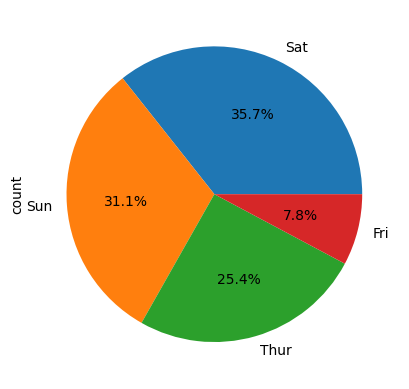

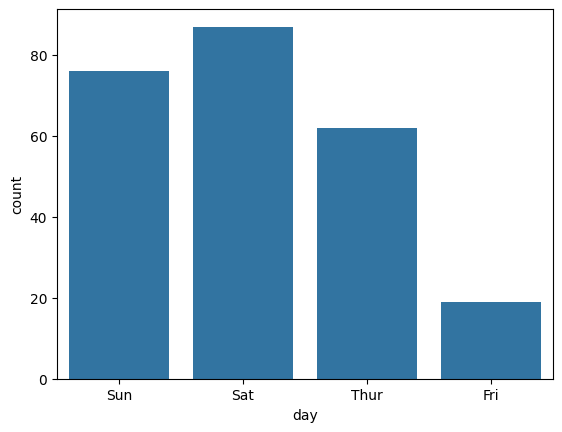

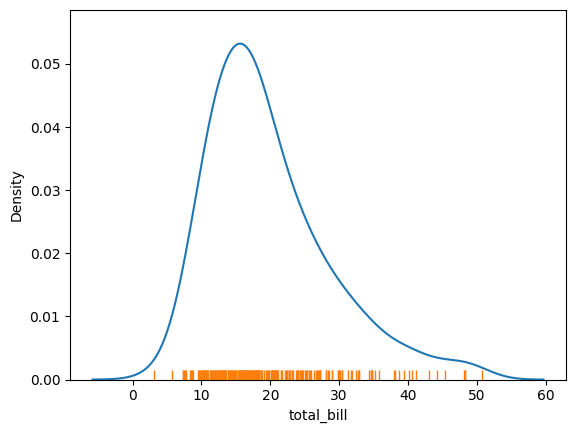

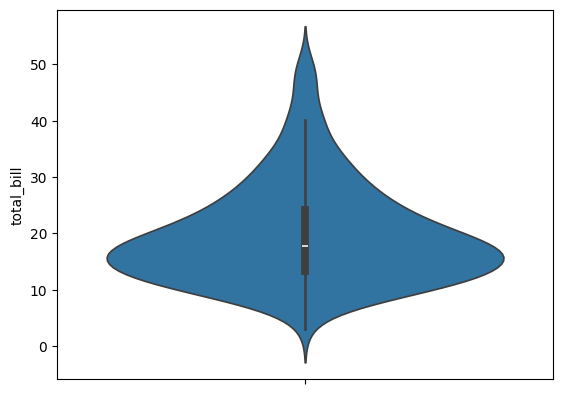

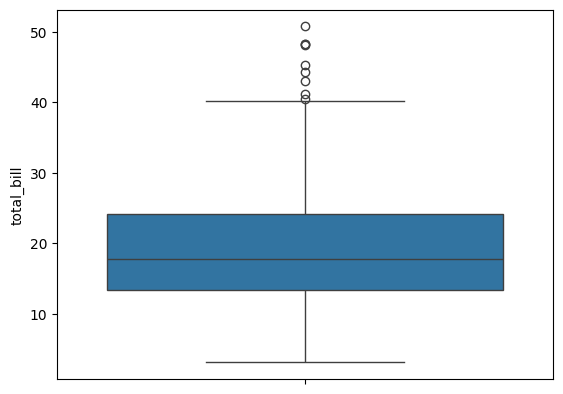

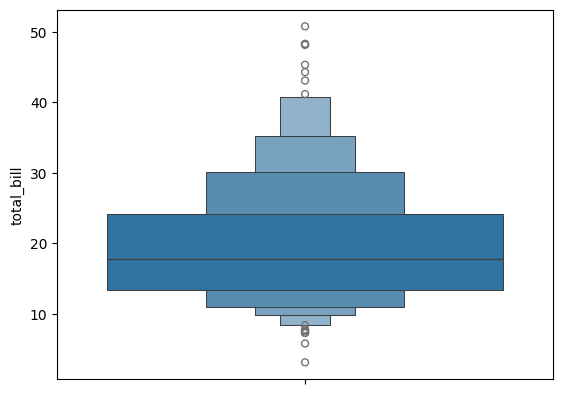

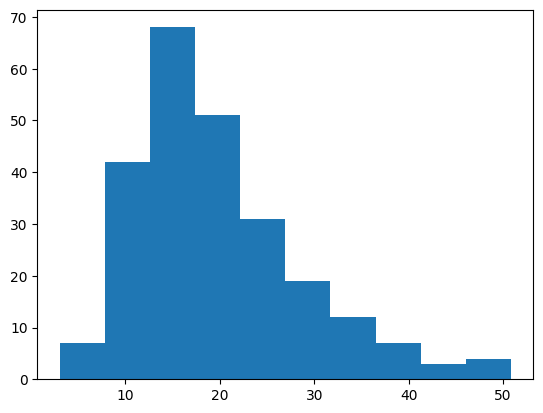

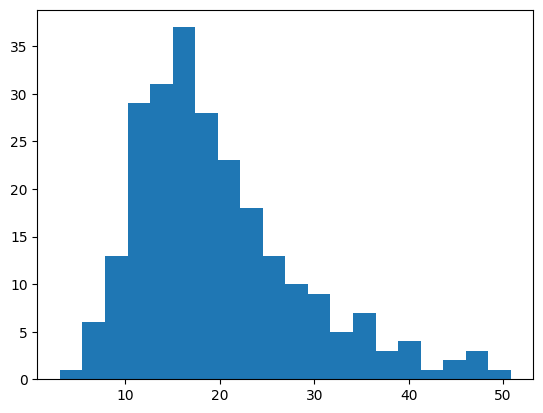

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pie chart
tips["day"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

# Count plot
sns.countplot(x="day", data=tips)
plt.show()

# KDE + Rug plot
sns.kdeplot(tips["total_bill"])
sns.rugplot(tips["total_bill"])
plt.show()

# Violin plot
sns.violinplot(y=tips["total_bill"])
plt.show()

# Box plot
sns.boxplot(y=tips["total_bill"])
plt.show()

# Boxen plot
sns.boxenplot(y=tips["total_bill"])
plt.show()

# Histogram
plt.hist(tips["total_bill"], bins=10)
plt.show()

# Histogram with different bins
plt.hist(tips["total_bill"], bins=20)
plt.show()


## Question 14: Bivariate analysis

**Tasks**

- Draw at least one graph of each type: scatter plot, line plot, joint plot, hexbin plot, 2D KDE plot, box plot, violin plot, swarm plot and count plot.

**How to do it**

Bivariate means two columns at a time. Choose the pair according to their types. For two numerical columns (for example total_bill and tip) use the scatter plot, joint plot, hexbin plot and 2D KDE plot; the hexbin and 2D KDE show density and are useful when points overlap heavily, where darker areas mean more points. For a trend over time use a line plot with the climate dataset, after converting the date column to real dates. For one categorical and one numerical column (for example day and total_bill) use the box plot, violin plot and swarm plot; swarm plots are slow on large data, so use a small dataset. For two categorical columns (for example Pclass and Survived) use a count plot and split the bars by the second column using colors. In your notes, say whether you see a relationship between the two columns.

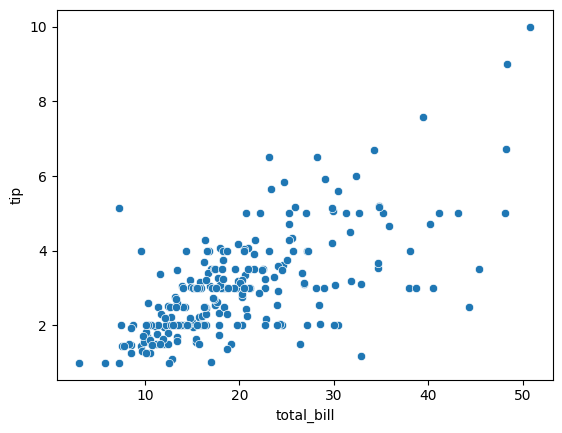

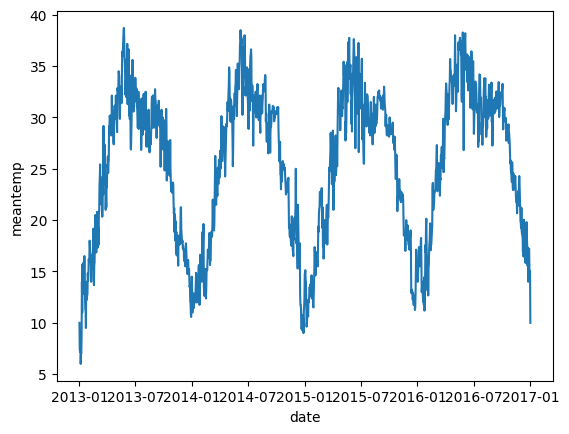

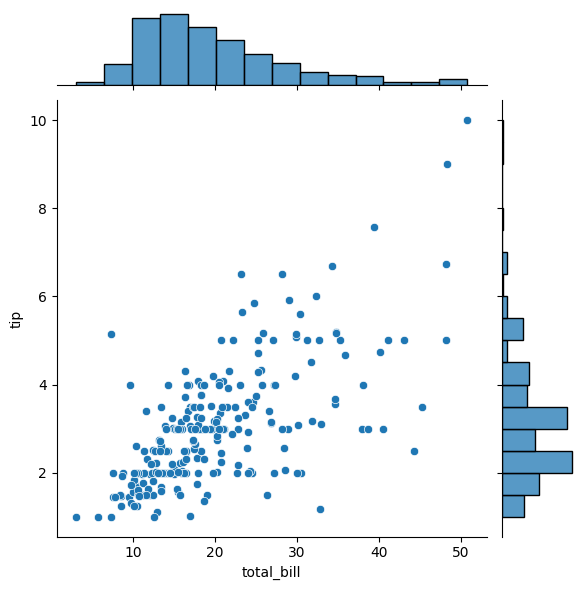

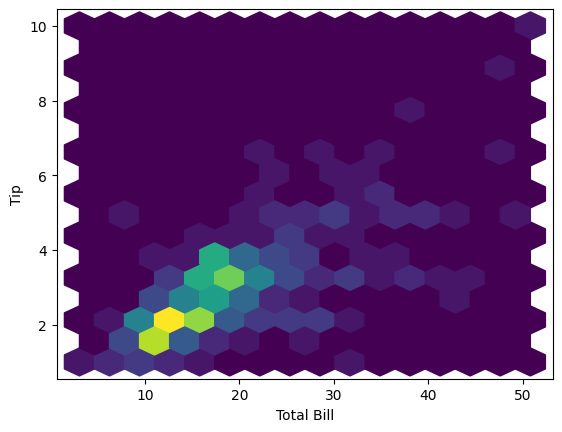

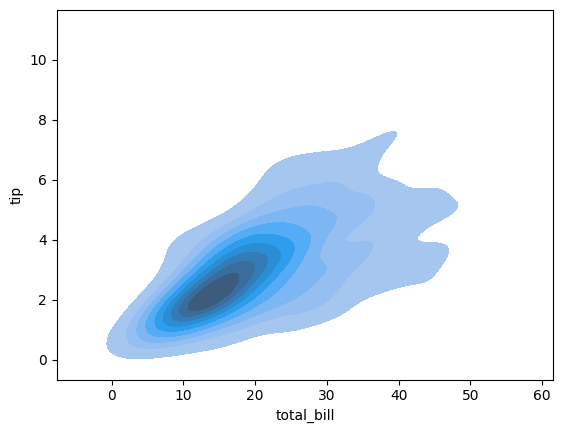

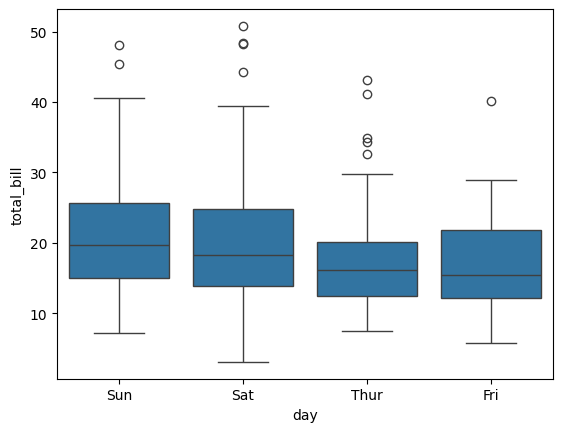

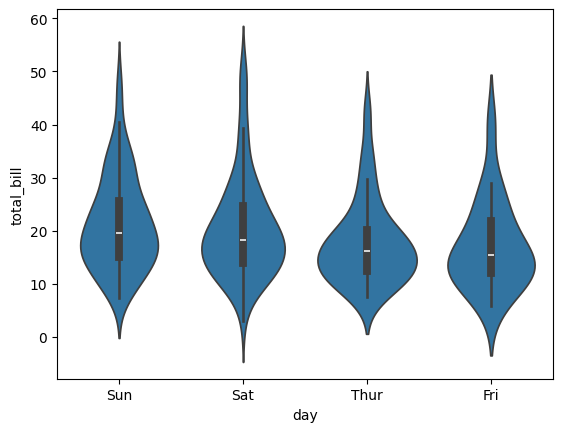

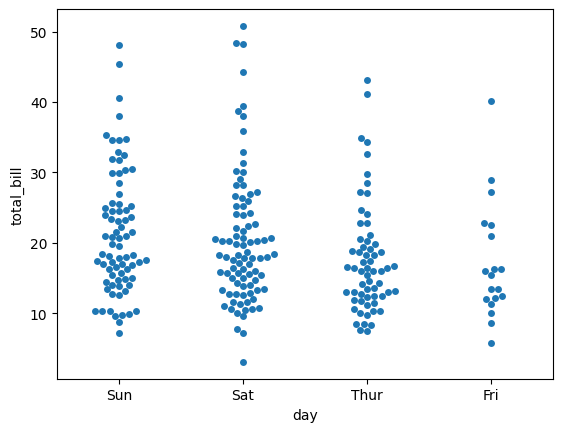

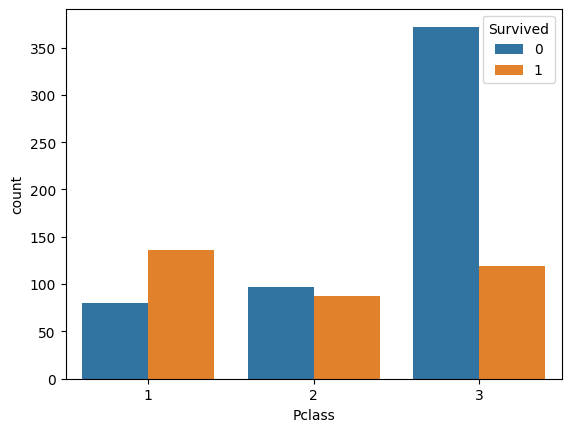

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter plot
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.show()

# 2. Line plot
sns.lineplot(x=climate.index, y=climate["meantemp"])
plt.show()

# 3. Joint plot
sns.jointplot(x="total_bill", y="tip", data=tips)
plt.show()

# 4. Hexbin plot
plt.hexbin(tips["total_bill"], tips["tip"], gridsize=15)
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

# 5. 2D KDE plot
sns.kdeplot(x=tips["total_bill"], y=tips["tip"], fill=True)
plt.show()

# 6. Box plot
sns.boxplot(x="day", y="total_bill", data=tips)
plt.show()

# 7. Violin plot
sns.violinplot(x="day", y="total_bill", data=tips)
plt.show()

# 8. Swarm plot
sns.swarmplot(x="day", y="total_bill", data=tips)
plt.show()

# 9. Count plot
sns.countplot(x="Pclass", hue="Survived", data=titanic)
plt.show()


## Question 15: Multivariate analysis

**Tasks**

- Draw at least one graph of each type: scatter plot, pair plot, heatmap, FacetGrid plot, PairGrid, joint plot and boxen plot.

**How to do it**

Multivariate means three or more columns together. For the scatter plot, add extra columns by using color, size and marker style for different columns. For the pair plot and PairGrid, use the iris dataset and color by species; the pair plot is automatic, while PairGrid lets you choose what to draw on the diagonal and off the diagonal. For the heatmap, first calculate the correlation of the numerical columns only (text columns will cause errors), then show it with values written in the cells; values near 1 or negative 1 mean a strong relationship. For the FacetGrid, split the data by one or two categorical columns so you get one small plot per group, and draw the same plot type in each. For the joint plot and the boxen plot, bring in a third column through color grouping. Write down at least two findings from these plots.

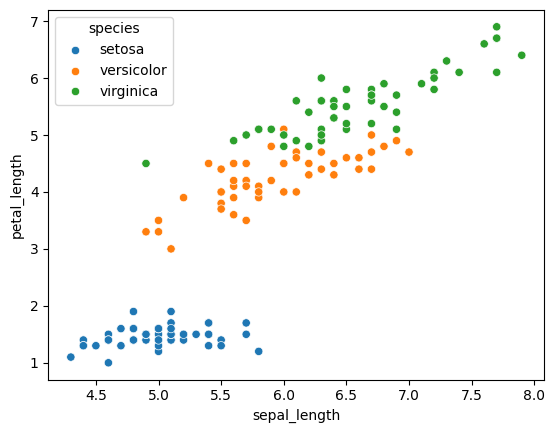

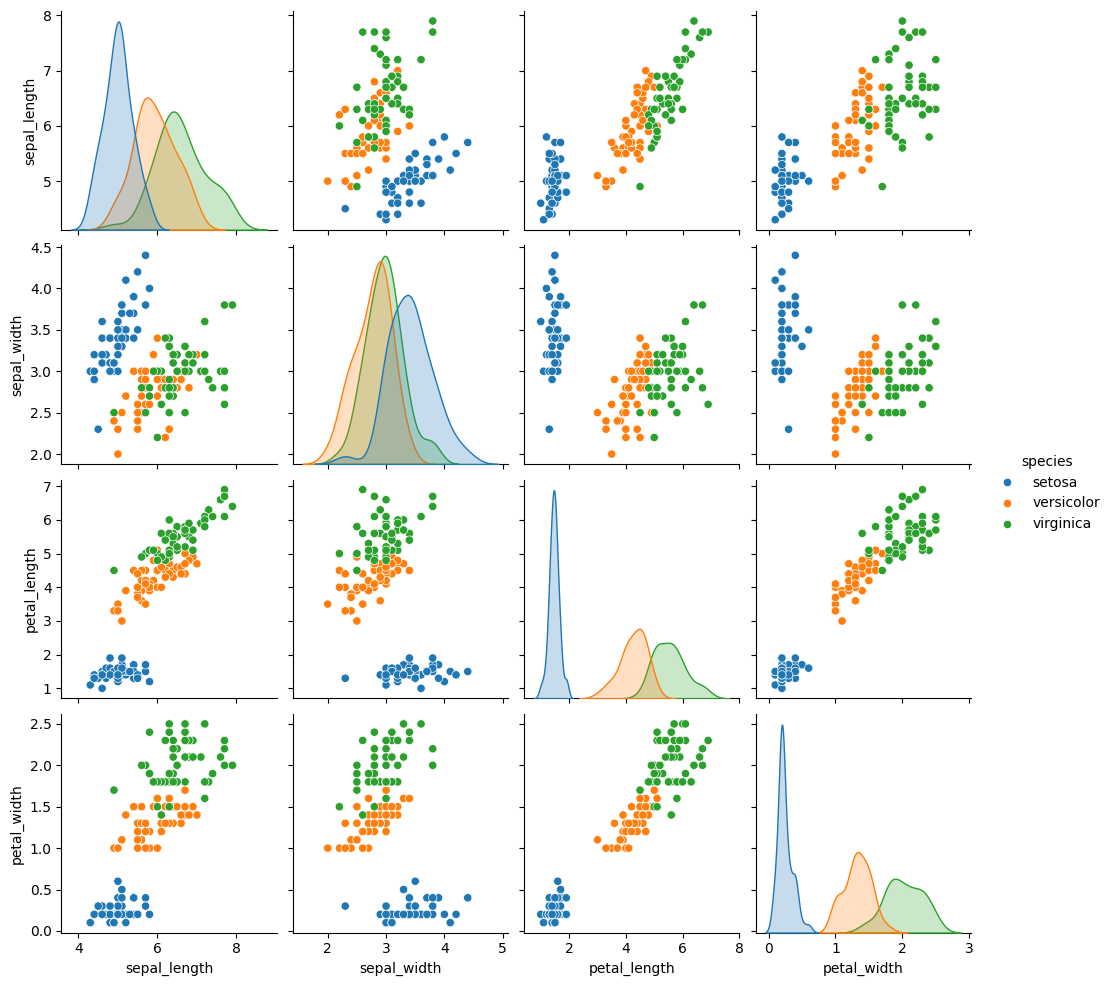

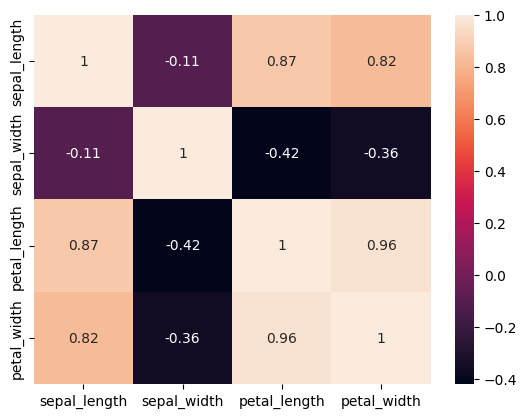

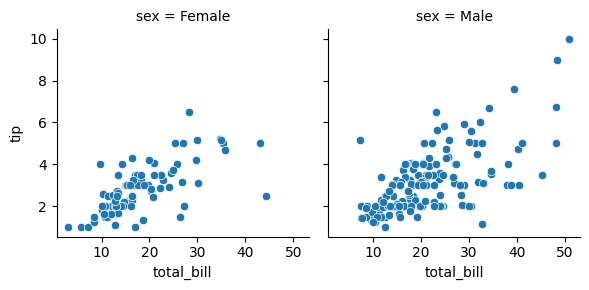

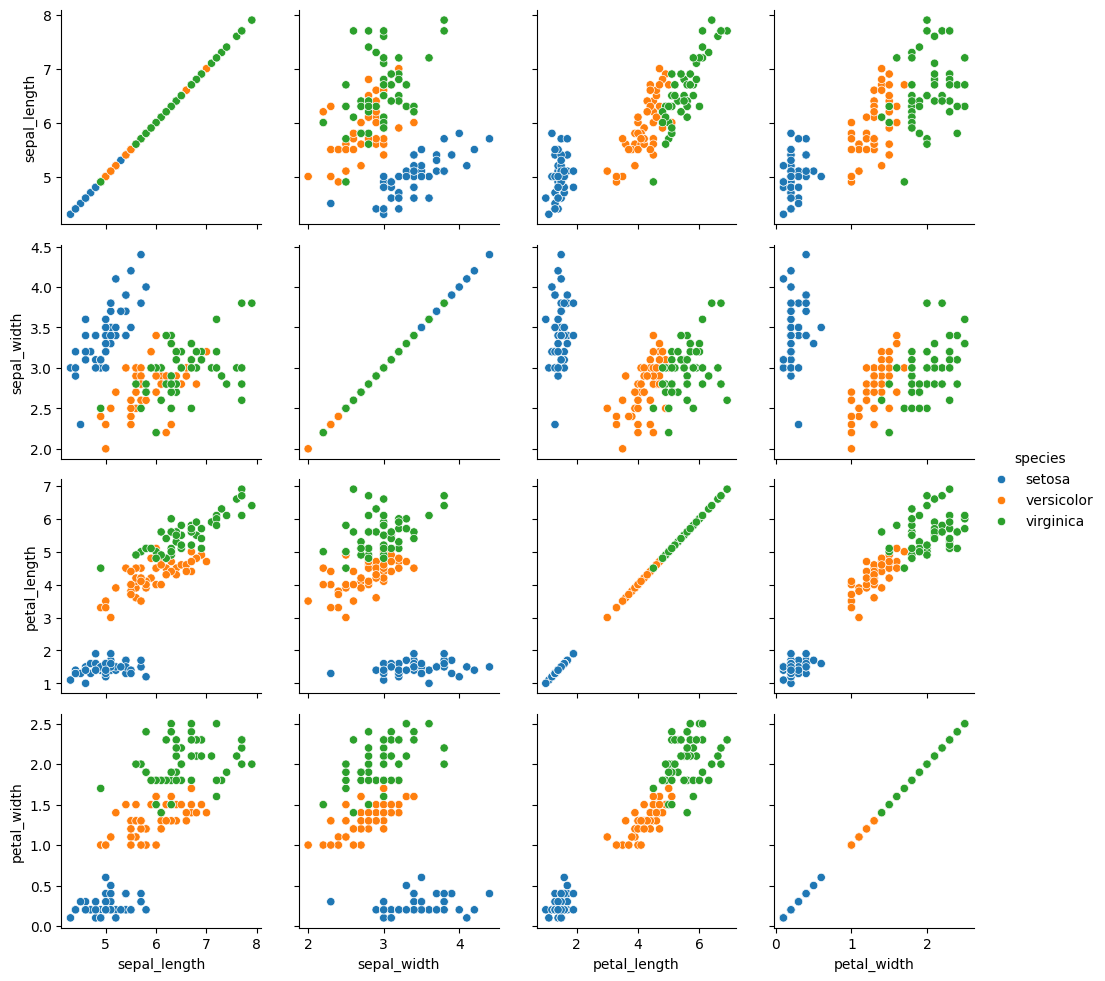

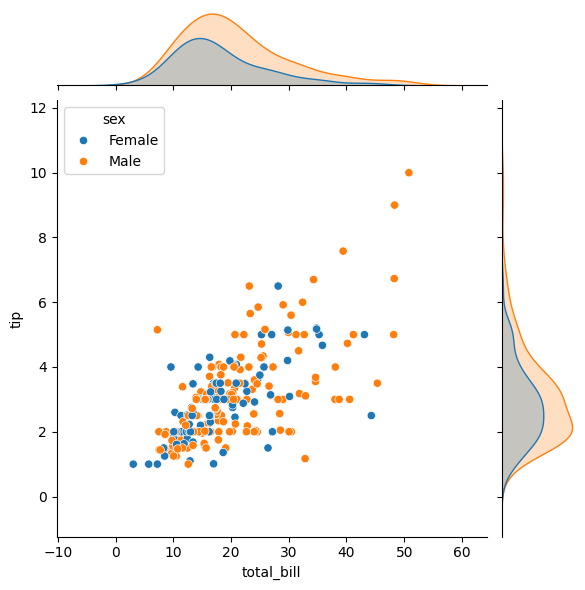

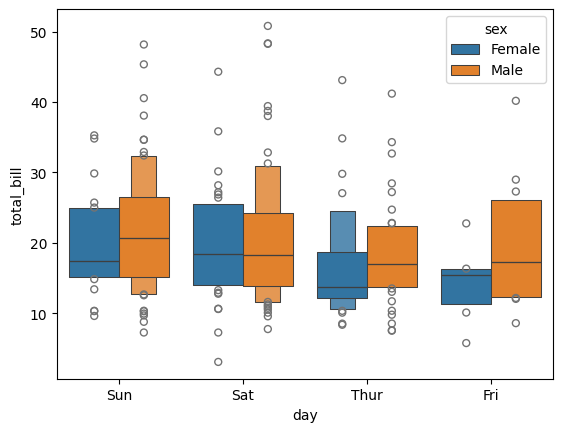

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=iris)
plt.show()

# Pair plot
sns.pairplot(iris, hue="species")
plt.show()

# Heatmap
sns.heatmap(iris.select_dtypes("number").corr(), annot=True)
plt.show()

# FacetGrid
sns.FacetGrid(tips, col="sex").map(sns.scatterplot, "total_bill", "tip")
plt.show()

# PairGrid
g = sns.PairGrid(iris, hue="species")
g.map(sns.scatterplot)
g.add_legend()
plt.show()

# Joint plot
sns.jointplot(x="total_bill", y="tip", hue="sex", data=tips)
plt.show()

# Boxen plot
sns.boxenplot(x="day", y="total_bill", hue="sex", data=tips)
plt.show()
